# Population Stratification in Latent Space — All Experiments

Iterates over every experiment directory found under `BASE_DIR` and produces the
standard population-stratification plots for each, saving PNGs into that
experiment's own `vae_outputs/latents/` folder.

- **Pop 0** = CEU (discovery / source population)
- **Pop 1** = YRI (target population)

Pre- and post-training projections share the **same PCA fit** per experiment so
the axes are directly comparable within each run.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

POP_NAMES  = {0: "CEU (disc train)", 1: "YRI (target train)"}
POP_COLORS = {0: "#2166ac", 1: "#d6604d"}
MARKERS    = {0: "s", 1: "^"}
POP_SHORT  = {0: "CEU", 1: "YRI"}
N_COMPONENTS = 2
ALPHA = 0.45
POINT_SIZE = 8


def load_phase(latents_dir: Path, phase: str):
    splits = ["disc_train", "target_train"]
    zt_parts, zd_parts, lab_parts = [], [], []
    for split in splits:
        zt  = np.load(latents_dir / f"{split}_{phase}_z_task.npy")
        zd  = np.load(latents_dir / f"{split}_{phase}_z_domain.npy")
        lab = np.load(latents_dir / f"{split}_{phase}_pop_labels.npy")
        zt_parts.append(zt); zd_parts.append(zd); lab_parts.append(lab)
    return (
        np.concatenate(zt_parts, axis=0),
        np.concatenate(zd_parts, axis=0),
        np.concatenate(lab_parts, axis=0),
    )


def make_shared_pca(data_pre: np.ndarray, data_post: np.ndarray, n_components: int = 2):
    combined = np.concatenate([data_pre, data_post], axis=0)
    scaler = StandardScaler()
    combined_scaled = scaler.fit_transform(combined)
    pca = PCA(n_components=n_components)
    pca.fit(combined_scaled)
    proj_pre  = pca.transform(scaler.transform(data_pre))
    proj_post = pca.transform(scaler.transform(data_post))
    return proj_pre, proj_post, pca.explained_variance_ratio_


def scatter_pca(ax, proj, labels, var, title):
    for pop_id in np.unique(labels):
        mask = labels == pop_id
        ax.scatter(
            proj[mask, 0], proj[mask, 1],
            c=POP_COLORS.get(pop_id, "grey"),
            label=POP_NAMES.get(pop_id, str(pop_id)),
            alpha=ALPHA, s=POINT_SIZE, linewidths=0,
        )
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)", fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, markerscale=2)


def centroid_separation(proj, labels):
    pops = np.unique(labels)
    centroids = [proj[labels == p].mean(axis=0) for p in pops]
    dist = np.linalg.norm(centroids[0] - centroids[1])
    spread = proj.std(axis=0).mean()
    return dist / (spread + 1e-9)

In [2]:
BASE_DIR = Path("/sietch_colab/akapoor/XPopVAE/experiments/OOA/vae/0/rep0")

In [3]:
exp_dirs = sorted([
    d for d in BASE_DIR.iterdir()
    if d.is_dir() and (d / "vae_outputs" / "latents").exists()
])
print(f"Found {len(exp_dirs)} experiment(s):")
for d in exp_dirs:
    print(f"  {d.name}")

Found 4 experiment(s):
  vae__mmd_delta0
  vae__mmd_delta1
  vae__mmd_delta10
  vae__mmd_delta5



Experiment: vae__mmd_delta0
pre  — z_task: (981, 64)  z_domain: (981, 64)
post — z_task: (981, 64)  z_domain: (981, 64)


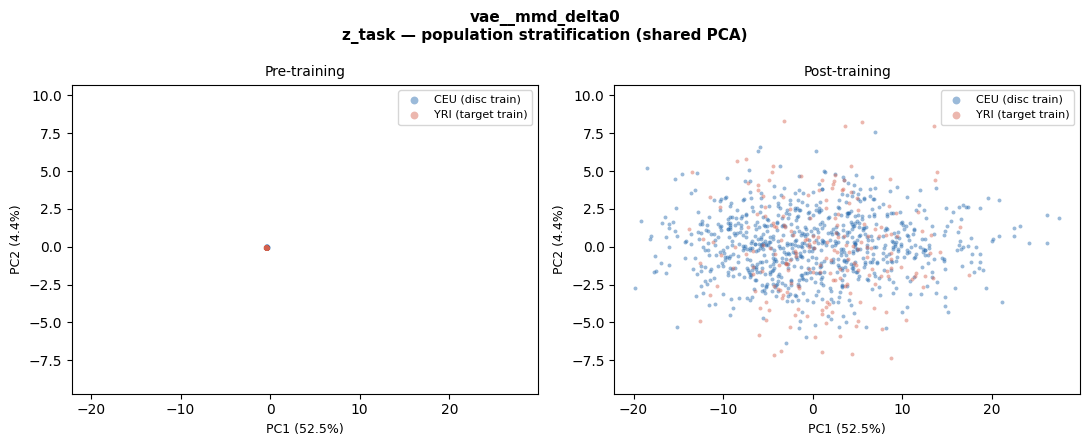

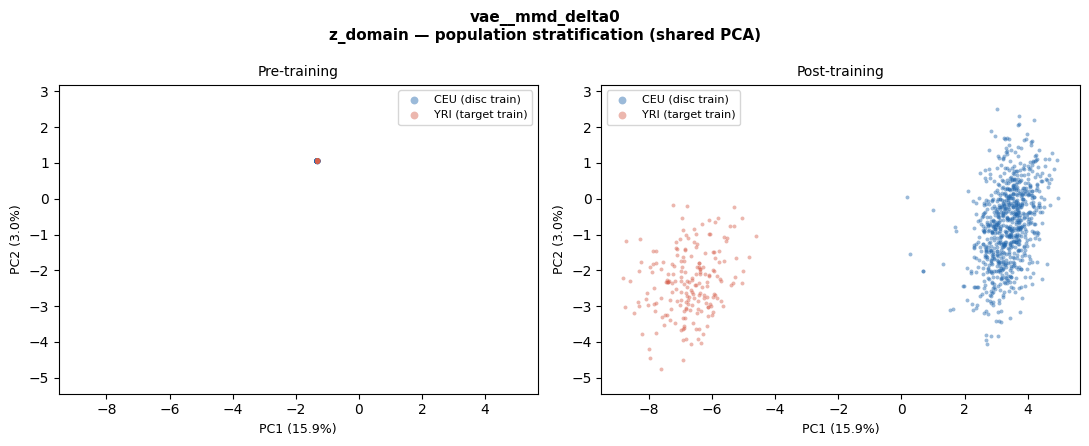

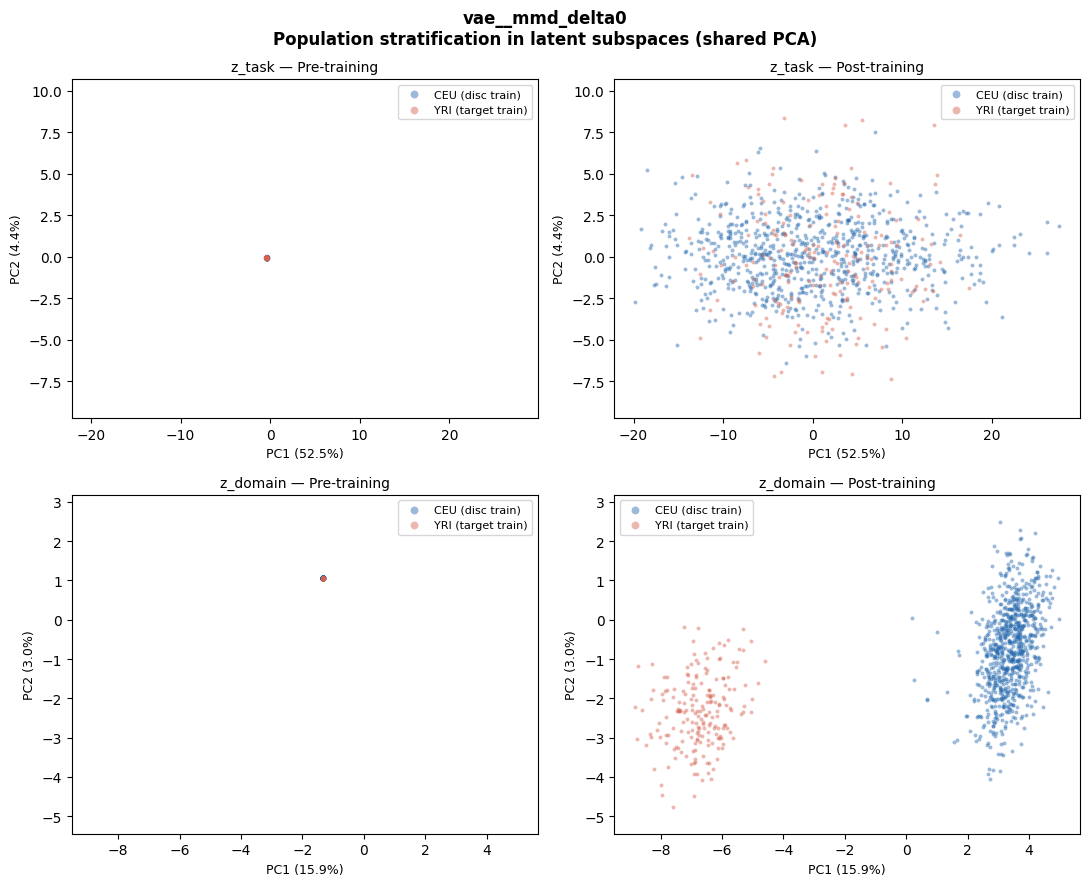


Centroid separation (higher = more stratified):
  z_task  pre: 1.429
  z_task  post: 0.174
  z_domain pre: 0.765
  z_domain post: 3.816

Silhouette score (higher = more stratified):
  z_task  pre: 0.138
  z_task  post: -0.041
  z_domain pre: 0.023
  z_domain post: 0.849


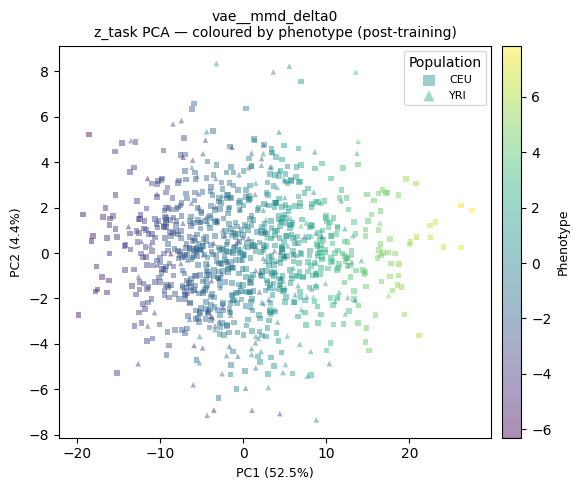


Experiment: vae__mmd_delta1
pre  — z_task: (981, 64)  z_domain: (981, 64)
post — z_task: (981, 64)  z_domain: (981, 64)


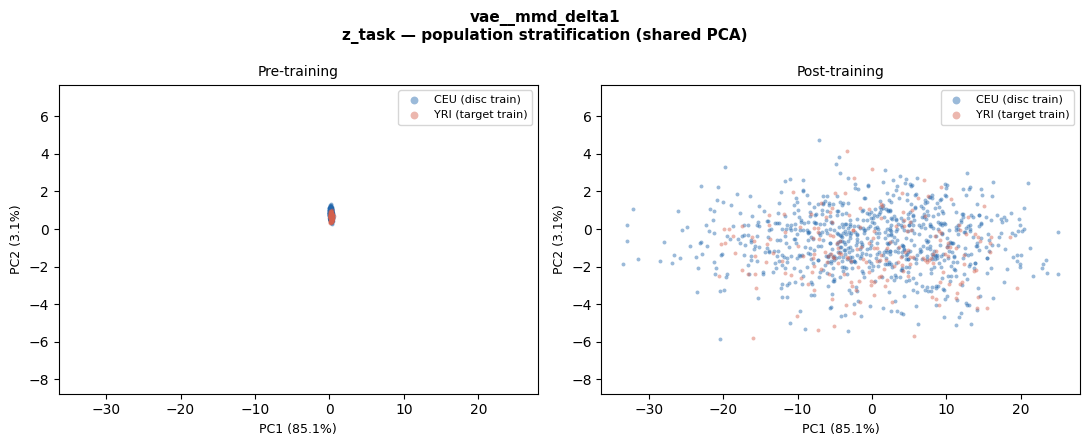

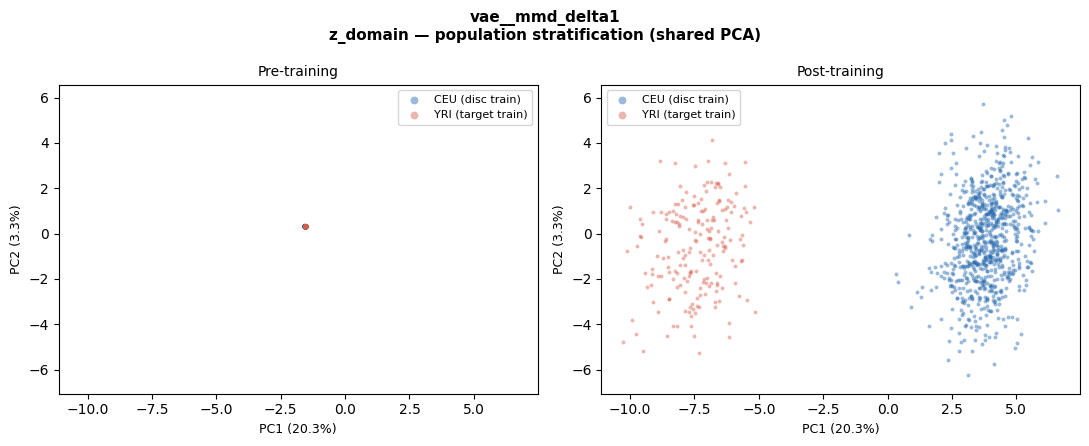

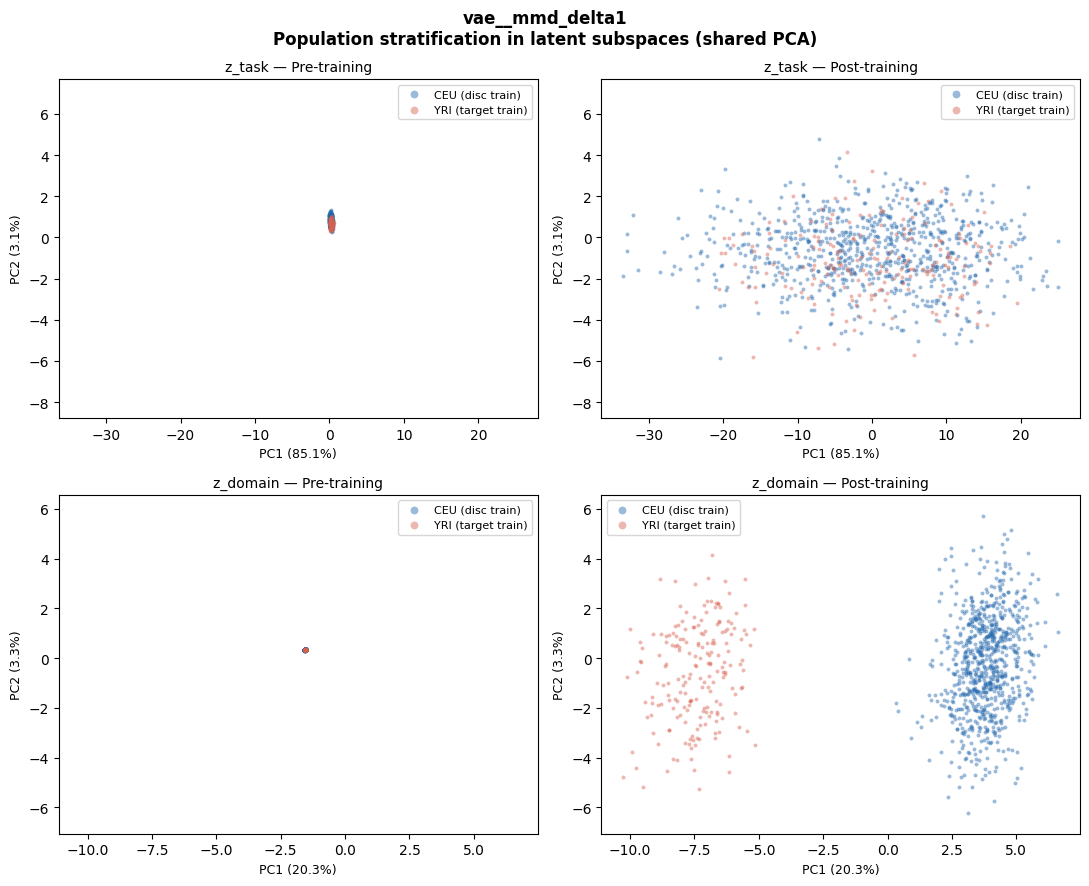


Centroid separation (higher = more stratified):
  z_task  pre: 1.155
  z_task  post: 0.091
  z_domain pre: 0.651
  z_domain post: 3.414

Silhouette score (higher = more stratified):
  z_task  pre: 0.069
  z_task  post: -0.040
  z_domain pre: -0.001
  z_domain post: 0.768


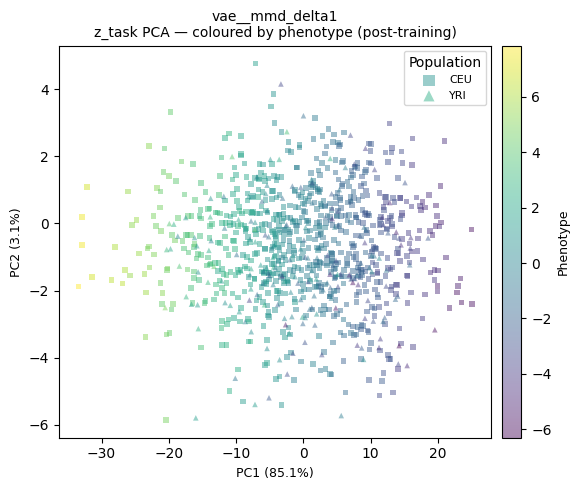


Experiment: vae__mmd_delta10
pre  — z_task: (981, 64)  z_domain: (981, 64)
post — z_task: (981, 64)  z_domain: (981, 64)


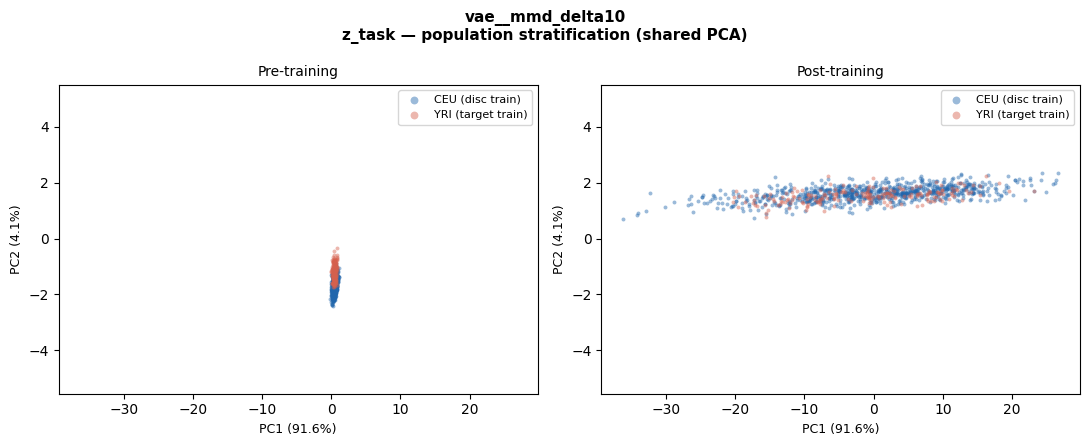

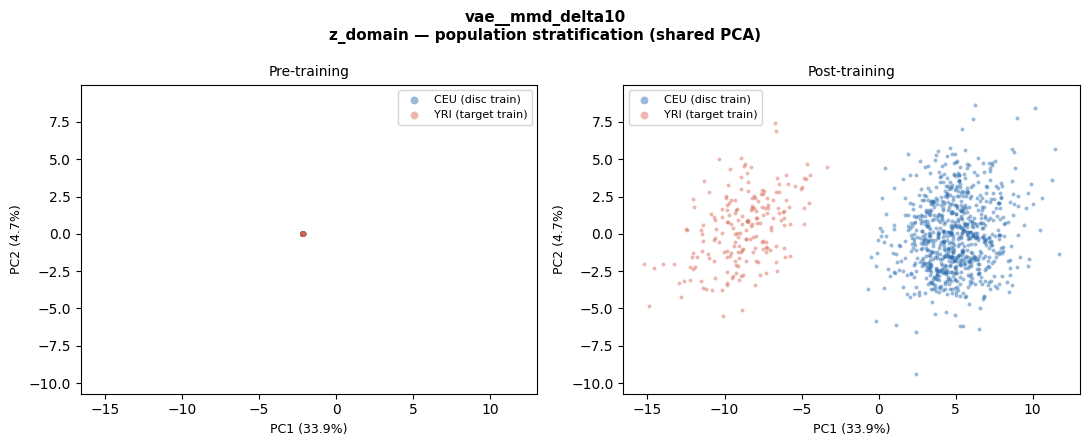

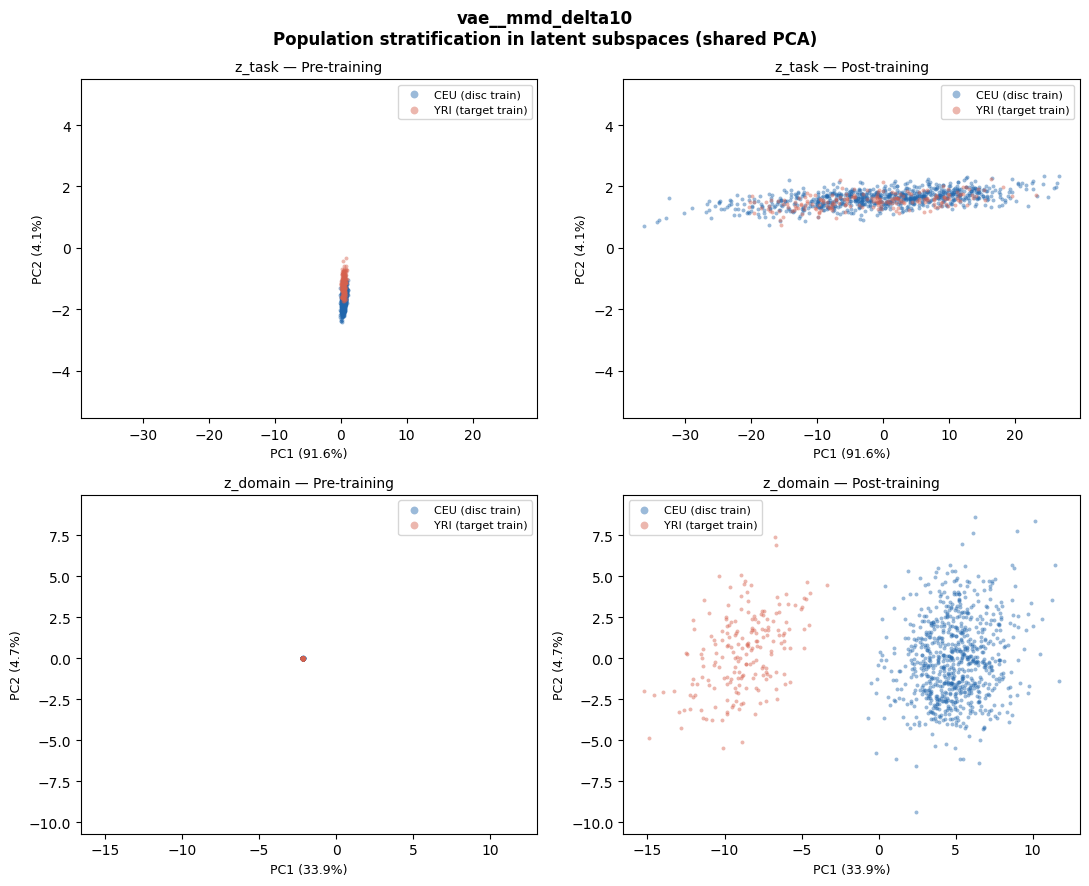


Centroid separation (higher = more stratified):
  z_task  pre: 1.920
  z_task  post: 0.232
  z_domain pre: 0.534
  z_domain post: 3.303

Silhouette score (higher = more stratified):
  z_task  pre: 0.292
  z_task  post: -0.035
  z_domain pre: 0.028
  z_domain post: 0.718


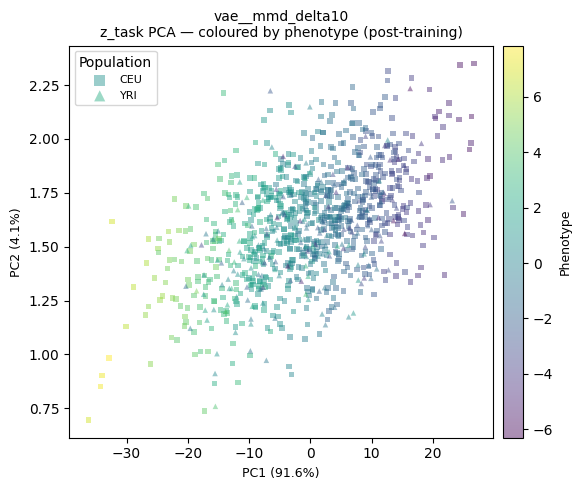


Experiment: vae__mmd_delta5
pre  — z_task: (981, 64)  z_domain: (981, 64)
post — z_task: (981, 64)  z_domain: (981, 64)


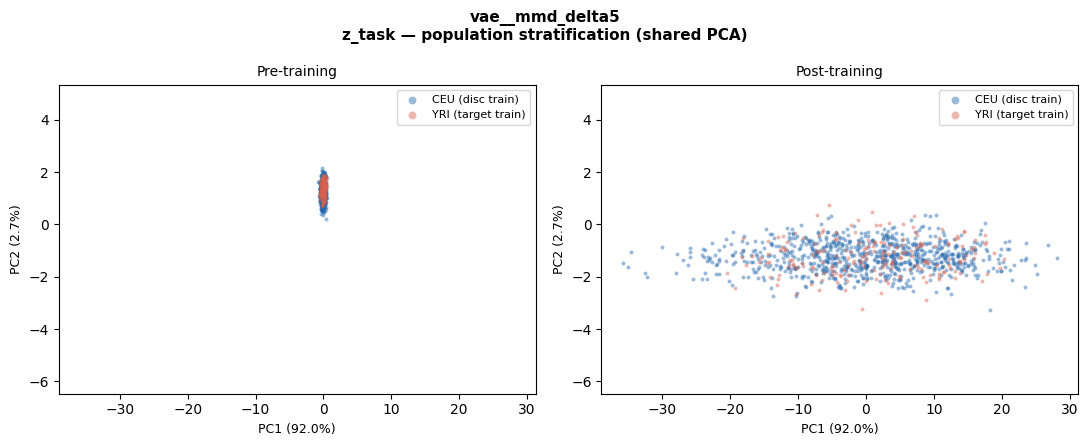

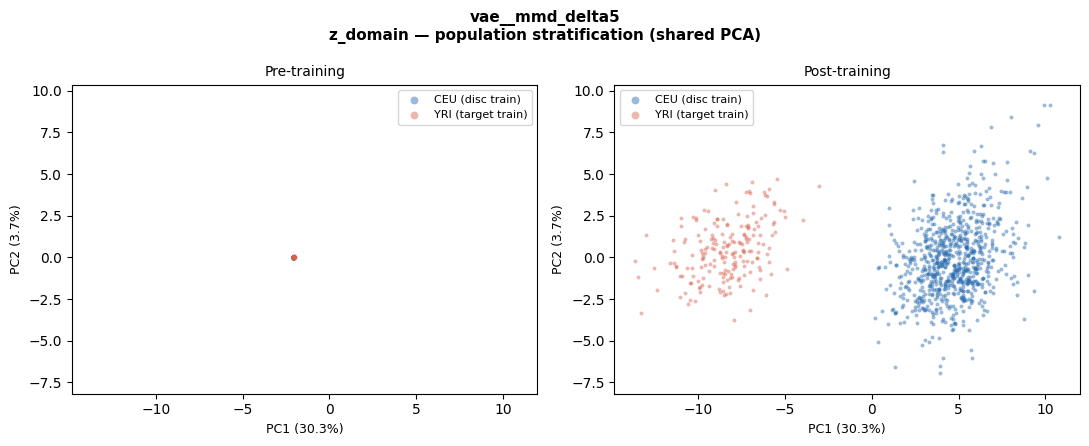

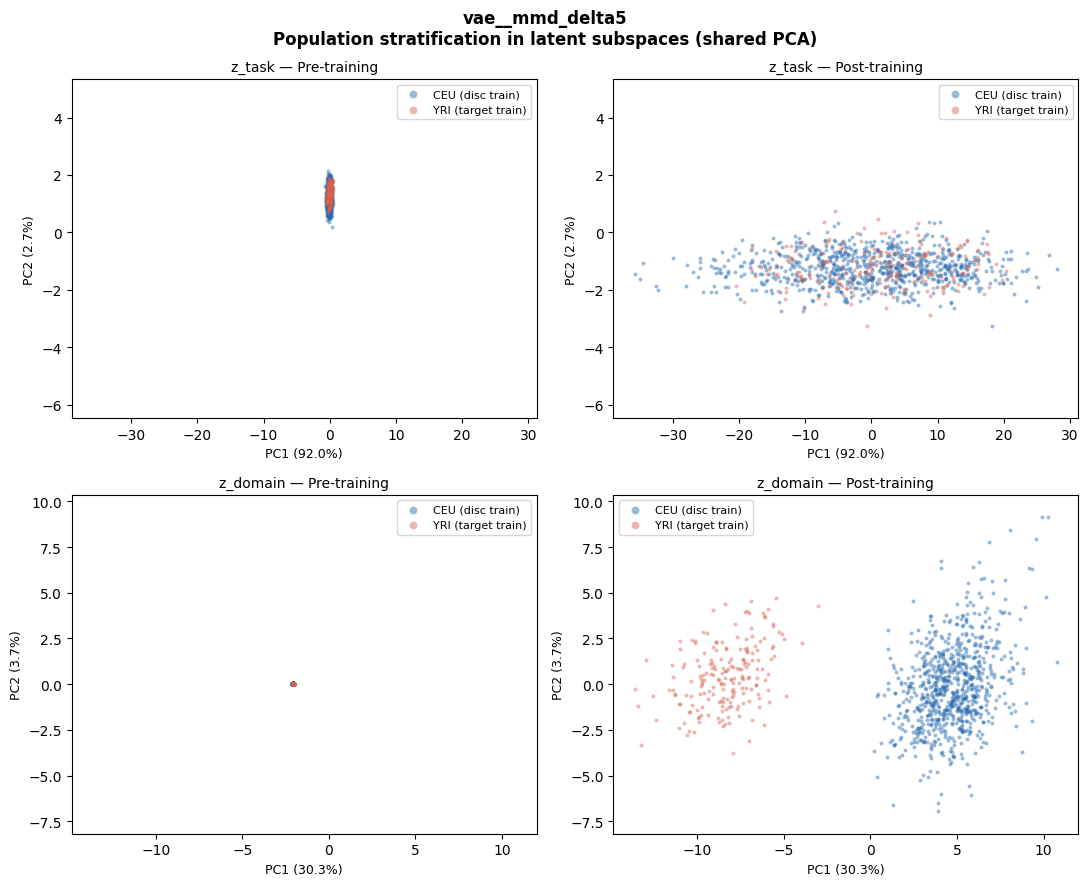


Centroid separation (higher = more stratified):
  z_task  pre: 0.534
  z_task  post: 0.191
  z_domain pre: 1.629
  z_domain post: 3.395

Silhouette score (higher = more stratified):
  z_task  pre: -0.002
  z_task  post: -0.045
  z_domain pre: 0.214
  z_domain post: 0.744


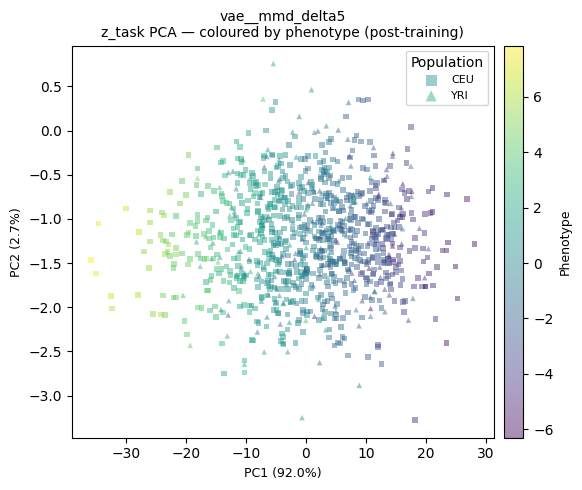

In [4]:
for exp_dir in exp_dirs:
    latents_dir = exp_dir / "vae_outputs" / "latents"
    pheno_dir   = exp_dir / "training_inputs"
    exp_name    = exp_dir.name
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_name}")
    print(f"{'='*60}")

    # load
    zt_pre,  zd_pre,  labels_pre  = load_phase(latents_dir, "pre_training")
    zt_post, zd_post, labels_post = load_phase(latents_dir, "post_training")
    print(f"pre  — z_task: {zt_pre.shape}  z_domain: {zd_pre.shape}")
    print(f"post — z_task: {zt_post.shape}  z_domain: {zd_post.shape}")

    # shared PCAs
    zt_proj_pre, zt_proj_post, zt_var = make_shared_pca(zt_pre, zt_post, N_COMPONENTS)
    zd_proj_pre, zd_proj_post, zd_var = make_shared_pca(zd_pre, zd_post, N_COMPONENTS)

    # Fig 1: z_task pop stratification
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.suptitle(f"{exp_name}\nz_task — population stratification (shared PCA)", fontsize=11, fontweight="bold")
    scatter_pca(axes[0], zt_proj_pre,  labels_pre,  zt_var, "Pre-training")
    scatter_pca(axes[1], zt_proj_post, labels_post, zt_var, "Post-training")
    for ax in axes:
        all_x = np.concatenate([zt_proj_pre[:, 0], zt_proj_post[:, 0]])
        all_y = np.concatenate([zt_proj_pre[:, 1], zt_proj_post[:, 1]])
        pad = 0.05 * (all_x.max() - all_x.min())
        ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
        ax.set_ylim(all_y.min() - pad, all_y.max() + pad)
    plt.tight_layout()
    plt.savefig(latents_dir / "pca_z_task_pop_stratification.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Fig 2: z_domain pop stratification
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.suptitle(f"{exp_name}\nz_domain — population stratification (shared PCA)", fontsize=11, fontweight="bold")
    scatter_pca(axes[0], zd_proj_pre,  labels_pre,  zd_var, "Pre-training")
    scatter_pca(axes[1], zd_proj_post, labels_post, zd_var, "Post-training")
    for ax in axes:
        all_x = np.concatenate([zd_proj_pre[:, 0], zd_proj_post[:, 0]])
        all_y = np.concatenate([zd_proj_pre[:, 1], zd_proj_post[:, 1]])
        pad = 0.05 * (all_x.max() - all_x.min())
        ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
        ax.set_ylim(all_y.min() - pad, all_y.max() + pad)
    plt.tight_layout()
    plt.savefig(latents_dir / "pca_z_domain_pop_stratification.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Fig 3: 2x2 overview
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    fig.suptitle(f"{exp_name}\nPopulation stratification in latent subspaces (shared PCA)", fontsize=12, fontweight="bold")
    scatter_pca(axes[0, 0], zt_proj_pre,  labels_pre,  zt_var, "z_task — Pre-training")
    scatter_pca(axes[0, 1], zt_proj_post, labels_post, zt_var, "z_task — Post-training")
    scatter_pca(axes[1, 0], zd_proj_pre,  labels_pre,  zd_var, "z_domain — Pre-training")
    scatter_pca(axes[1, 1], zd_proj_post, labels_post, zd_var, "z_domain — Post-training")
    for row_axes, pre_proj, post_proj in [
        (axes[0], zt_proj_pre, zt_proj_post),
        (axes[1], zd_proj_pre, zd_proj_post),
    ]:
        all_x = np.concatenate([pre_proj[:, 0], post_proj[:, 0]])
        all_y = np.concatenate([pre_proj[:, 1], post_proj[:, 1]])
        pad = 0.05 * (all_x.max() - all_x.min())
        for ax in row_axes:
            ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
            ax.set_ylim(all_y.min() - pad, all_y.max() + pad)
    plt.tight_layout()
    plt.savefig(latents_dir / "pca_overview_2x2.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Quantitative metrics
    print("\nCentroid separation (higher = more stratified):")
    for label, proj, lab in [
        ("z_task  pre",   zt_proj_pre,  labels_pre),
        ("z_task  post",  zt_proj_post, labels_post),
        ("z_domain pre",  zd_proj_pre,  labels_pre),
        ("z_domain post", zd_proj_post, labels_post),
    ]:
        print(f"  {label}: {centroid_separation(proj, lab):.3f}")

    print("\nSilhouette score (higher = more stratified):")
    for label, proj, lab in [
        ("z_task  pre",   zt_proj_pre,  labels_pre),
        ("z_task  post",  zt_proj_post, labels_post),
        ("z_domain pre",  zd_proj_pre,  labels_pre),
        ("z_domain post", zd_proj_post, labels_post),
    ]:
        score = silhouette_score(proj, lab) if len(np.unique(lab)) > 1 else float("nan")
        print(f"  {label}: {score:.3f}")

    # Fig 4: z_task post coloured by phenotype
    pheno_post = np.concatenate([
        np.load(pheno_dir / "discovery_train_pheno.npy"),
        np.load(pheno_dir / "target_train_pheno.npy"),
    ])
    fig, ax = plt.subplots(figsize=(6, 5))
    vmin, vmax = pheno_post.min(), pheno_post.max()
    for pop_id in np.unique(labels_post):
        mask = labels_post == pop_id
        sc = ax.scatter(
            zt_proj_post[mask, 0], zt_proj_post[mask, 1],
            c=pheno_post[mask], cmap="viridis", vmin=vmin, vmax=vmax,
            marker=MARKERS[pop_id], label=POP_SHORT[pop_id],
            alpha=ALPHA, s=POINT_SIZE * 2, linewidths=0,
        )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("Phenotype", fontsize=9)
    ax.set_xlabel(f"PC1 ({zt_var[0]*100:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({zt_var[1]*100:.1f}%)", fontsize=9)
    ax.set_title(f"{exp_name}\nz_task PCA — coloured by phenotype (post-training)", fontsize=10)
    ax.legend(title="Population", fontsize=8, markerscale=2)
    fig.tight_layout()
    plt.savefig(latents_dir / "pca_z_task_phenotype.png", dpi=150, bbox_inches="tight")
    plt.show()